In [84]:

from torchvision import datasets
import numpy as np
from PIL import Image
from pathlib import Path
from matplotlib import pyplot as plt

In [85]:
data=datasets.MNIST(root='data/mnist',train=True,download=True)
test=datasets.MNIST(root='data/mnist',train=False,download=True)
train_data=data.data.numpy()
train_label=data.targets.numpy()
test_data=test.data.numpy()
test_label=test.targets.numpy()
print('tain data size:',train_data.shape,"labels shape:",train_label.shape)
print('test data size:',test_data.shape,'labels shape:',test_label.shape)


tain data size: (60000, 28, 28) labels shape: (60000,)
test data size: (10000, 28, 28) labels shape: (10000,)


In [86]:
class MyLiner():
    def __init__(self,out_shape):
        self.out_shape=out_shape
        self.w=None
        self.b=None
        self.name=None
        self.x=None
        self.num=1
        self.sloy=None
        self.y=None

    def build(self,x_shape):
        self.w=np.random.normal(0,np.sqrt(2/x_shape[-1]),size=(x_shape[-1],self.out_shape))
        self.b=np.zeros(self.out_shape,np.float32)
        
    def backprop(self,y,grad):
        dy=np.matmul(y,self.w.T)
        grad[self.name]={'w':np.matmul(self.x.T,y),"b":np.sum(y,axis=0)}
        return (dy,grad)

    def update(self,grads_new):
         self.w-=grads_new[self.name]['w']
         self.b-=grads_new[self.name]['b']
         grads_new.pop(self.name)
         return grads_new
         
    def __call__(self,x):
        if type(x)==np.ndarray:
                x1=x
        else:
                x1=x.y

        if self.w is None:
            self.build(x1.shape)
            
        if self.name is None:
            if type(x)==np.ndarray:
                self.name=f'layers_liner-{self.num}'
            else:
                 self.num=x.num
                 self.name=f"layers_liner-{self.num}"
                 self.sloy=x
            self.num+=1
        self.x=x1
        self.y=np.matmul(x1,self.w)+self.b
        return self
    

class MyReLU():
    def __init__(self):
        self.name=None
        self.num=1
        self.y=None
        self.sloy=None

    def backprop(self,y,grad):
         mask=np.asarray(self.y!=0.0,np.float32)
         return (y*mask,grad)

    def update(self,grads_new):
         return grads_new
    
    def __call__(self,x):
        if self.name is None:
                if type(x)==np.ndarray:
                    self.name=f'layers_relu-{self.num}'
                else:
                    self.num=x.num
                    self.name=f"layers_relu-{self.num}"
                    self.sloy=x
                self.num+=1
        if type(x)==np.ndarray:
             x1=x
        else:
             x1=x.y
        self.y=np.maximum(x1,np.zeros_like(x1,dtype=np.float32))
        return self

    
class NN():
    def __init__(self):
        self.liner1=MyLiner(64)
        self.relu1=MyReLU()
        self.liner2=MyLiner(32)
        self.relu2=MyReLU()
        self.liner3=MyLiner(10)

    def backprop(self,correct):
         sloy=self.sloy
         grad={}
         y=self.y- correct
         while sloy is not None:
              y,grad=sloy.backprop(y,grad)
              sloy=sloy.sloy
         return grad

    def update(self,grads_new):
         sloy=self.sloy
         while sloy is not None:
              grads_new=sloy.update(grads_new)
              sloy=sloy.sloy
    
    def __call__(self,x):
        x1=self.liner1(x)
        x2=self.relu1(x1)
        x3=self.liner2(x2)
        x4=self.relu2(x3)
        x5=self.liner3(x4)
        self.sloy=x5
        
        self.y=np.exp(x5.y)/np.expand_dims(np.sum(np.exp(x5.y),axis=-1),axis=-1)
        return self.y


In [87]:
class MyAdam():
    def __init__(self,lr=0.001,b1=0.9,b2=0.999,eps=1e-8):
        self.lr=lr
        self.b1=b1
        self.b2=b2
        self.eps=eps
        self.t=0

    def apply_optimizer(self,grad):
        self.t+=1
        self.m={}
        self.v={}
        self.weights={}
        for k,v in grad.items():
            if not k in self.weights:
                self.weights[k]={}
            if not k in self.m:
                self.m[k]={}
                self.v[k]={}
                
            for k1,v1 in v.items():
                self.weights[k][k1]={}
                if not k1 in self.m[k].keys():
                    self.m[k][k1]=(1-self.b1)*v1
                    self.v[k][k1]=(1-self.b2)*np.square(v1)
                else:
                    self.m[k][k1]=self.b1*self.m[k][k1]+(1-self.b1)*v1
                    self.v[k][k1]=self.b2*self.v[k][k1] + (1-self.b2)*np.square(v1)

                m_c= self.m[k][k1]/(1-np.pow(self.b1,self.t))
                v_c= self.v[k][k1]/(1-np.pow(self.b2,self.t))

                self.weights[k][k1]=(self.lr/(np.sqrt(v_c)+self.eps))*m_c
        
        return self.weights
            



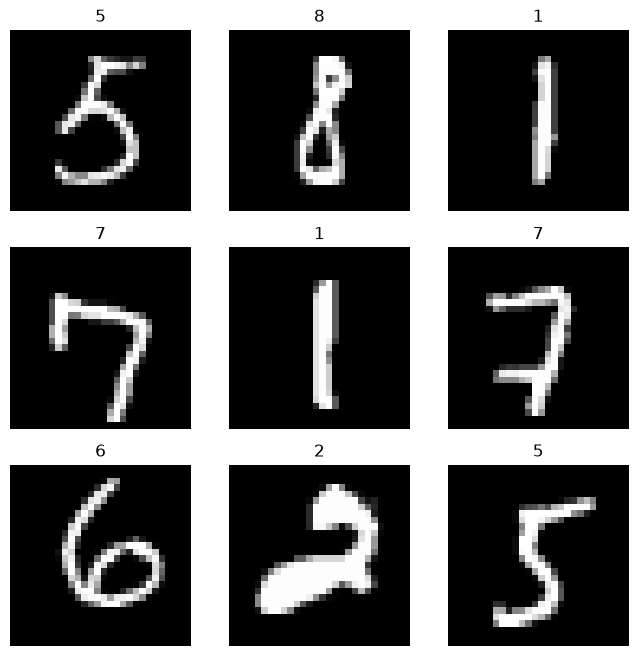

In [88]:
ind=np.arange(0,train_data.shape[0],1,dtype=np.int32)
np.random.shuffle(ind)
plt.figure(figsize=(8,8))
for i,index in enumerate(ind[:9]):

    plt.subplot(3,3,i+1)
    plt.imshow(train_data[index],cmap='gray')
    plt.axis('off')
    plt.title(train_label[index])
plt.show()

In [89]:
model=NN()

ind=np.arange(0,train_data.shape[0],1,dtype=np.int32)
np.random.shuffle(ind)
optimizer=MyAdam()

for i in range(0,len(ind),32):

        x=train_data[ind[i:i+32]]
        y_pred_n=train_label[ind[i:i+32]]

        x=np.reshape(x/255.0,(-1,28*28))
        y_pred= np.eye(10,10,dtype=np.float32)[y_pred_n]

        y=model(x)
        loss=np.mean(-np.log(y[np.arange(32),y_pred_n]))
        grad=model.backprop(y_pred)
        grad=optimizer.apply_optimizer(grad)
    
        model.update(grad)

        acur=np.sum(np.array(np.argmax(y,axis=-1)==y_pred_n,dtype=np.float32))

        if i%(32*5)==0:
            print(f'i:{i}| Loss: {loss}| acur: {acur}')



i:0| Loss: 2.257231385550193| acur: 6.0
i:160| Loss: 2.030133952777793| acur: 12.0
i:320| Loss: 2.0542827351957875| acur: 9.0
i:480| Loss: 2.0463665037022247| acur: 13.0
i:640| Loss: 1.7770639625565967| acur: 15.0
i:800| Loss: 1.7081717933399059| acur: 14.0
i:960| Loss: 1.5083137676753577| acur: 19.0
i:1120| Loss: 1.6183587551560998| acur: 12.0
i:1280| Loss: 1.4516846492197228| acur: 20.0
i:1440| Loss: 1.3770305437944221| acur: 21.0
i:1600| Loss: 1.2767630657923195| acur: 22.0
i:1760| Loss: 1.223923173200782| acur: 23.0
i:1920| Loss: 1.2054747920834237| acur: 20.0
i:2080| Loss: 0.9107050349898922| acur: 23.0
i:2240| Loss: 1.148365592418102| acur: 21.0
i:2400| Loss: 1.1506047913541448| acur: 23.0
i:2560| Loss: 0.8565377368143738| acur: 24.0
i:2720| Loss: 0.7680886714127155| acur: 26.0
i:2880| Loss: 0.8527138119376659| acur: 26.0
i:3040| Loss: 0.9135592678777962| acur: 26.0
i:3200| Loss: 0.7813974146398862| acur: 27.0
i:3360| Loss: 0.6867995585064093| acur: 25.0
i:3520| Loss: 0.682222787

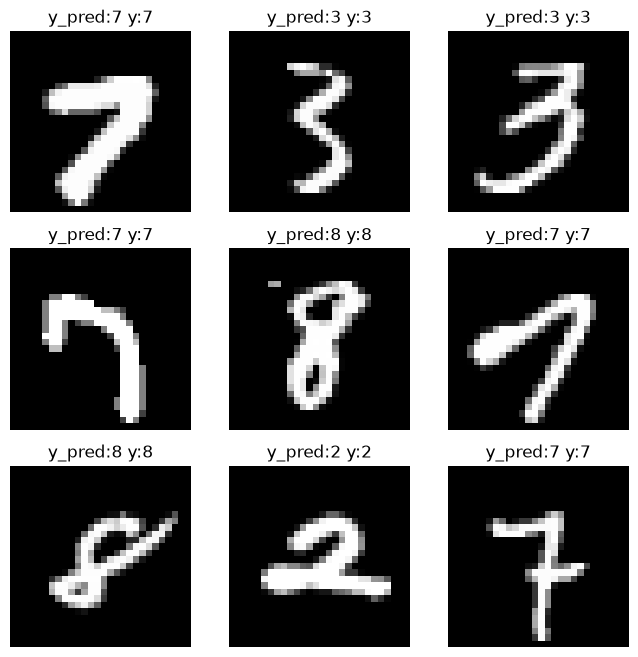

In [92]:
ind=np.arange(0,test_data.shape[0],1,dtype=np.int32)
np.random.shuffle(ind)
plt.figure(figsize=(8,8))
for i,index in enumerate(ind[:9]):

    plt.subplot(3,3,i+1)
    plt.imshow(test_data[index],cmap='gray')
    plt.axis('off')
    plt.title(f"y_pred:{test_label[index]} y:{np.argmax(model(np.reshape(test_data[index]/255.0,(-1,28*28))))}")
plt.show()

In [91]:
ind=np.arange(0,test_data.shape[0],1,dtype=np.int32)
np.random.shuffle(ind)
correct=0
for i in range(0,len(ind),64):

    x=test_data[ind[i:i+64]]
    y_pred_n=test_label[ind[i:i+64]]

    x=np.reshape(x/255.0,(-1,28*28))
    y=np.argmax(model(x),axis=-1)
    correct+=np.sum(y==y_pred_n)
print('correct:',correct)
print('dont correct:', ind.shape[0]-correct)


correct: 9105
dont correct: 895
